# 6. Modelagem — Classificação por threshold

Sexta etapa do trabalho, ainda dentro da fase de *Modeling* do CRISP-DM. A pergunta original era se o NPS poderia ser previsto com base em dados operacionais. No notebook anterior respondi com uma regressão linear simples, que entrega um valor numérico de 0 a 10. Aqui dou o passo seguinte: transformar esse valor numérico em uma decisão binária — o cliente vai ser detrator ou não?

Esse formato é mais útil para a operação. Um gerente de SAC não precisa saber se o NPS predito é 5,4 ou 6,2; ele precisa saber se aquele pedido merece um contato proativo ou não. A regra para virar a régua é direta: defino um corte (`threshold`) e classifico como detrator todo cliente cujo NPS predito ficar abaixo desse corte.

A diferença entre este notebook e o anterior é só de leitura. Não treino nenhum modelo novo: reaproveito a regressão do notebook 05 e estudo o efeito de variar o threshold sobre as métricas de classificação.


## 6.1 Carregamento e setup

Mesmo padrão dos notebooks anteriores. Carrego o dataset processado pela função do módulo `src/nps/data.py`, configuro o tema visual e defino os caminhos de saída para figuras desta fase.


In [1]:
# Bibliotecas principais
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Modelo e metricas
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
)

# Funcoes do nosso modulo
from nps.data import carregar_dataset_processado

# Reprodutibilidade
SEMENTE_ALEATORIA = 42
np.random.seed(SEMENTE_ALEATORIA)

# Configuracao visual
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 100

# Cores semanticas reaproveitadas do projeto
cores_buckets = {"detrator": "#e74c3c", "neutro": "#95a5a6", "promotor": "#27ae60"}

# Caminhos para esse notebook
RAIZ_PROJETO = Path.cwd().parent
PASTA_FIGURAS = RAIZ_PROJETO / "reports" / "figures" / "06_modelagem_classificacao"
PASTA_FIGURAS.mkdir(parents=True, exist_ok=True)

# Carrega o dataset processado
dados = carregar_dataset_processado()

print(f"Dataset carregado: {dados.shape[0]:,} linhas x {dados.shape[1]} colunas")


Dataset carregado: 2,500 linhas x 23 colunas


Tudo carregado. A próxima seção define o que significa "ser detrator" no contexto deste notebook e olha como essa classe se distribui na base.


## 6.2 Definição do target binário

A regra original do NPS define três grupos: detrator (nota 0–6), neutro (7–8) e promotor (9–10). Para classificação binária, junto neutros e promotores em uma única classe "não-detrator". A justificativa de negócio é simples: a operação quer saber em quem agir antes que o cliente vire reclamação. Neutros e promotores não precisam de ação imediata; detratores sim.

O target final é uma variável `eh_detrator` que vale 1 quando `nps_score < 7` e 0 caso contrário.


In [2]:
# Target binario: 1 = detrator, 0 = nao-detrator
dados["eh_detrator"] = (dados["nps_score"] < 7).astype(int)

# Distribuicao
contagem = dados["eh_detrator"].value_counts().rename({0: "Nao-detrator", 1: "Detrator"})
proporcao = dados["eh_detrator"].value_counts(normalize=True).rename({0: "Nao-detrator", 1: "Detrator"})

tabela = pd.DataFrame({
    "Quantidade": contagem,
    "Proporcao": proporcao.map(lambda x: f"{x:.1%}"),
})
print(tabela)


              Quantidade Proporcao
eh_detrator                       
Detrator            2109     84.4%
Nao-detrator         391     15.6%


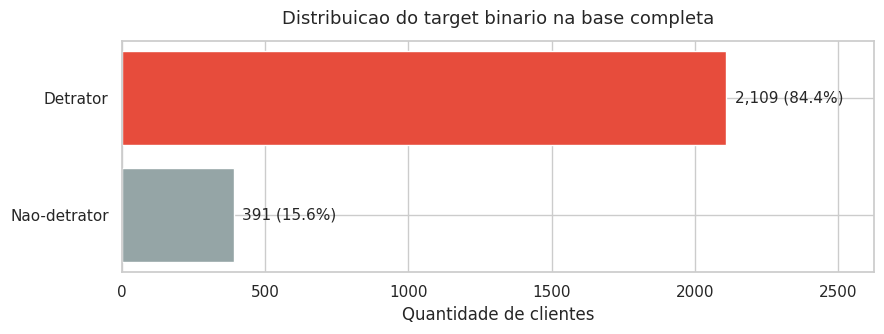

In [3]:
# Grafico de barras horizontal mostrando o desbalanceamento
fig, ax = plt.subplots(figsize=(9, 3.5))

qtd_det = (dados["eh_detrator"] == 1).sum()
qtd_nao = (dados["eh_detrator"] == 0).sum()
total = len(dados)

ax.barh(["Detrator", "Nao-detrator"],
        [qtd_det, qtd_nao],
        color=[cores_buckets["detrator"], cores_buckets["neutro"]],
        edgecolor="white")

# Anotacoes nas barras
for i, (qtd, label) in enumerate(zip([qtd_det, qtd_nao], ["Detrator", "Nao-detrator"])):
    ax.text(qtd + 30, i, f"{qtd:,} ({qtd/total:.1%})", va="center", fontsize=11)

ax.set_xlim(0, total * 1.05)
ax.set_xlabel("Quantidade de clientes")
ax.set_title("Distribuicao do target binario na base completa", fontsize=13, pad=12)
ax.invert_yaxis()

plt.tight_layout()
plt.savefig(PASTA_FIGURAS / "6_2_distribuicao_target.png", dpi=120, bbox_inches="tight")
plt.show()


![Distribuição do target binário detrator vs não-detrator](../reports/figures/06_modelagem_classificacao/6_2_distribuicao_target.png)


**Como ler este gráfico:** o eixo Y mostra as duas classes do target binário (detrator em vermelho, não-detrator em cinza). O eixo X é a quantidade de clientes em cada classe, com o número absoluto e a proporção anotados ao lado de cada barra. As cores são as mesmas usadas em todo o projeto: vermelho para detrator, cinza para não-detrator (que aqui agrega neutros e promotores).

A leitura é direta: a base é fortemente desbalanceada. Cerca de 85% dos clientes são detratores e 15% não são. Esse desbalanceamento tem uma consequência imediata para o trabalho de classificação: se eu fizer um modelo trivial que prevê "detrator" para todo mundo, sem olhar nenhuma variável, ele acerta 85% das vezes. Esse vai ser o **baseline** que qualquer threshold precisa superar para fazer sentido.

A próxima seção reaproveita o modelo de regressão do notebook 05 para gerar predições, e a seção 6.4 começa a comparar essas predições com o baseline trivial.


## 6.3 Modelo de regressão e geração das predições

Reproduzo o split e o ajuste do notebook 05 com a mesma semente, então o conjunto de teste deste notebook é exatamente o mesmo do anterior. Isso é importante porque qualquer comparação que eu fizer entre regressão e classificação precisa estar olhando para os mesmos 500 clientes.


In [4]:
# Variavel preditora (X) e target numerico (y)
X = dados[["delivery_delay_days"]]
y = dados["nps_score"]

# Mesmo split do notebook 05
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y,
    test_size=0.2,
    random_state=SEMENTE_ALEATORIA,
)

# Ajusta a regressao no treino
dados_treino = pd.concat([X_treino, y_treino], axis=1)
modelo = smf.ols("nps_score ~ delivery_delay_days", data=dados_treino).fit()

# Predicoes no teste
dados_teste = pd.concat([X_teste, y_teste], axis=1)
nps_predito_teste = modelo.predict(dados_teste)

# Target binario observado no teste
y_real_det = (y_teste < 7).astype(int).reset_index(drop=True)
nps_predito_teste = nps_predito_teste.reset_index(drop=True)

print(f"Equacao da reta: nps_predito = {modelo.params['Intercept']:.3f} + ({modelo.params['delivery_delay_days']:.3f}) * delivery_delay_days")
print(f"Tamanho do conjunto de teste: {len(y_teste):,} clientes")
print(f"Detratores reais no teste:    {y_real_det.sum():,} ({y_real_det.mean():.1%})")
print(f"NPS predito range no teste:   {nps_predito_teste.min():.2f} a {nps_predito_teste.max():.2f}")


Equacao da reta: nps_predito = 6.628 + (-1.024) * delivery_delay_days
Tamanho do conjunto de teste: 500 clientes
Detratores reais no teste:    427 (85.4%)
NPS predito range no teste:   -1.57 a 6.63


Atenção a um detalhe que vai virar peça-chave da próxima seção. O **intercepto da regressão é 6,63**, ou seja, a previsão para um cliente com zero dias de atraso já fica abaixo de 7. E o coeficiente é negativo: cada dia adicional de atraso joga a previsão ainda mais para baixo. Isso significa que **todo cliente, independente do atraso, recebe um NPS predito menor que 7**. Esse fato vai determinar o que acontece com o threshold "óbvio" de 7.


## 6.4 O threshold "óbvio" de 7 e por que ele falha

A primeira escolha intuitiva de threshold é 7, exatamente o corte canônico do NPS (notas abaixo de 7 são detratores). Mas como o intercepto da regressão já está em 6,63, **nenhum cliente recebe predição maior ou igual a 7**. Isso transforma o classificador com threshold 7 em algo equivalente a "chutar detrator para todo mundo".

Vou aplicar o threshold de 7 no conjunto de teste, montar a matriz de confusão e comparar com o baseline trivial para deixar isso explícito.


In [5]:
# Aplica threshold = 7
threshold_obvio = 7.0
y_pred_det_t7 = (nps_predito_teste < threshold_obvio).astype(int)

# Metricas
acc_t7 = accuracy_score(y_real_det, y_pred_det_t7)
prec_t7 = precision_score(y_real_det, y_pred_det_t7, zero_division=0)
rec_t7 = recall_score(y_real_det, y_pred_det_t7, zero_division=0)
f1_t7 = f1_score(y_real_det, y_pred_det_t7, zero_division=0)

# Baseline trivial: chuta detrator para todos
y_pred_baseline = np.ones_like(y_real_det)
acc_baseline = accuracy_score(y_real_det, y_pred_baseline)

# Matriz de confusao
cm = confusion_matrix(y_real_det, y_pred_det_t7, labels=[1, 0])
tabela_cm = pd.DataFrame(
    cm,
    index=["Detrator real", "Nao-detrator real"],
    columns=["Predito detrator", "Predito nao-detrator"],
)

print("Matriz de confusao (threshold = 7):")
print(tabela_cm)
print()
print(f"Acuracia do classificador (t=7):  {acc_t7:.3f}")
print(f"Acuracia do baseline trivial:     {acc_baseline:.3f}")
print(f"Precisao (det. preditos que acertam): {prec_t7:.3f}")
print(f"Recall (det. reais capturados):       {rec_t7:.3f}")
print(f"F1:                                   {f1_t7:.3f}")


Matriz de confusao (threshold = 7):
                   Predito detrator  Predito nao-detrator
Detrator real                   427                     0
Nao-detrator real                73                     0

Acuracia do classificador (t=7):  0.854
Acuracia do baseline trivial:     0.854
Precisao (det. preditos que acertam): 0.854
Recall (det. reais capturados):       1.000
F1:                                   0.921


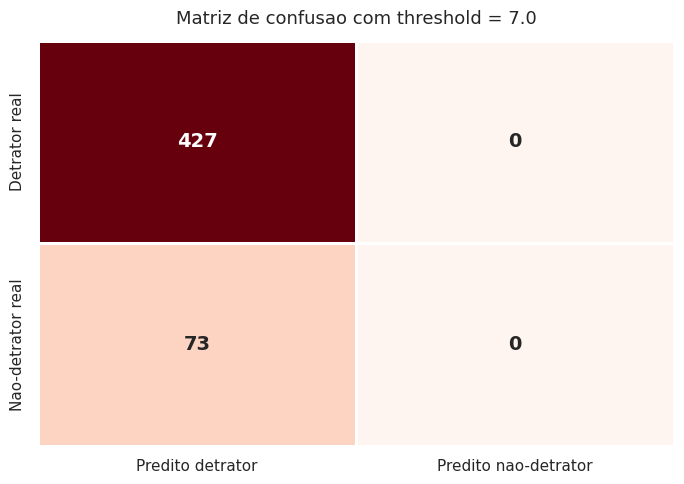

In [6]:
# Heatmap da matriz de confusao
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    tabela_cm,
    annot=True,
    fmt=",d",
    cmap="Reds",
    cbar=False,
    linewidths=1,
    linecolor="white",
    annot_kws={"fontsize": 14, "fontweight": "bold"},
    ax=ax,
)
ax.set_title(f"Matriz de confusao com threshold = {threshold_obvio}", fontsize=13, pad=12)
ax.set_xlabel("")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig(PASTA_FIGURAS / "6_4_matriz_confusao_t7.png", dpi=120, bbox_inches="tight")
plt.show()


![Matriz de confusão com threshold igual a 7](../reports/figures/06_modelagem_classificacao/6_4_matriz_confusao_t7.png)


**Como ler este gráfico:** uma matriz de confusão tem quatro caixas. As linhas representam o que **aconteceu de verdade** (cliente foi detrator ou não); as colunas representam o que o **modelo previu**. A diagonal principal é onde o modelo acertou: detrator real classificado como detrator (canto superior esquerdo) e não-detrator real classificado como não-detrator (canto inferior direito). A diagonal secundária é onde ele errou.

Os números nas caixas são quantidades absolutas de clientes. Quanto mais escuro o vermelho, maior o valor. A leitura crucial aqui é a coluna direita: ela está vazia. Com threshold 7, **o modelo nunca prediz "não-detrator"** — todas as previsões caem na coluna esquerda.

Olhando os números:

- 427 detratores reais foram preditos como detrator (acerto).
- 73 não-detratores reais também foram preditos como detrator (erro).
- Zero clientes foram preditos como não-detrator.

A acurácia de 85,4% bate exatamente com o baseline trivial. Isso confirma que o threshold 7 não está usando a informação da regressão para nada útil em termos de classificação: ele só replica o palpite ingênuo "todo mundo é detrator". O recall é 100% (capturei todos os detratores), mas pago o preço de não conseguir poupar ninguém: a operação teria que tratar os 500 clientes do teste como se todos fossem detratores.

Para o classificador agregar valor real, o threshold precisa ser **mais conservador**. Em outras palavras, exigir um NPS predito *bem* baixo antes de chamar o cliente de detrator. Isso é o que a próxima seção investiga.


## 6.5 Variação do threshold

O threshold 7 é degenerado, e qualquer valor maior também seria, porque o NPS predito máximo no teste é 6,63. Os pontos interessantes ficam **abaixo** desse intercepto. Vou varrer thresholds de 5,0 a 6,8 em passos de 0,1 e medir como acurácia, precisão, recall e F1 reagem.

A ideia é entender o trade-off operacional. Threshold mais baixo significa "só chamo de detrator quem o modelo tem muita certeza"; isso aumenta a precisão (menos falsos alarmes) mas diminui o recall (deixa detratores reais passarem batido). Threshold mais alto faz o oposto.


In [7]:
# Varredura de thresholds
thresholds = np.arange(5.0, 6.81, 0.1)

resultados = []
for t in thresholds:
    y_pred = (nps_predito_teste < t).astype(int)
    resultados.append({
        "threshold": round(t, 2),
        "acuracia": accuracy_score(y_real_det, y_pred),
        "precisao": precision_score(y_real_det, y_pred, zero_division=0),
        "recall":   recall_score(y_real_det, y_pred, zero_division=0),
        "f1":       f1_score(y_real_det, y_pred, zero_division=0),
        "preditos_detrator": int(y_pred.sum()),
    })

tabela_thresholds = pd.DataFrame(resultados)

# Mostra tabela enxuta
print("Variacao das metricas em funcao do threshold:")
print(tabela_thresholds.to_string(index=False))


Variacao das metricas em funcao do threshold:
 threshold  acuracia  precisao   recall       f1  preditos_detrator
       5.0     0.726  0.950311 0.716628 0.817089                322
       5.1     0.726  0.950311 0.716628 0.817089                322
       5.2     0.726  0.950311 0.716628 0.817089                322
       5.3     0.726  0.950311 0.716628 0.817089                322
       5.4     0.726  0.950311 0.716628 0.817089                322
       5.5     0.726  0.950311 0.716628 0.817089                322
       5.6     0.726  0.950311 0.716628 0.817089                322
       5.7     0.838  0.894977 0.918033 0.906358                438
       5.8     0.838  0.894977 0.918033 0.906358                438
       5.9     0.838  0.894977 0.918033 0.906358                438
       6.0     0.838  0.894977 0.918033 0.906358                438
       6.1     0.838  0.894977 0.918033 0.906358                438
       6.2     0.838  0.894977 0.918033 0.906358                438
  

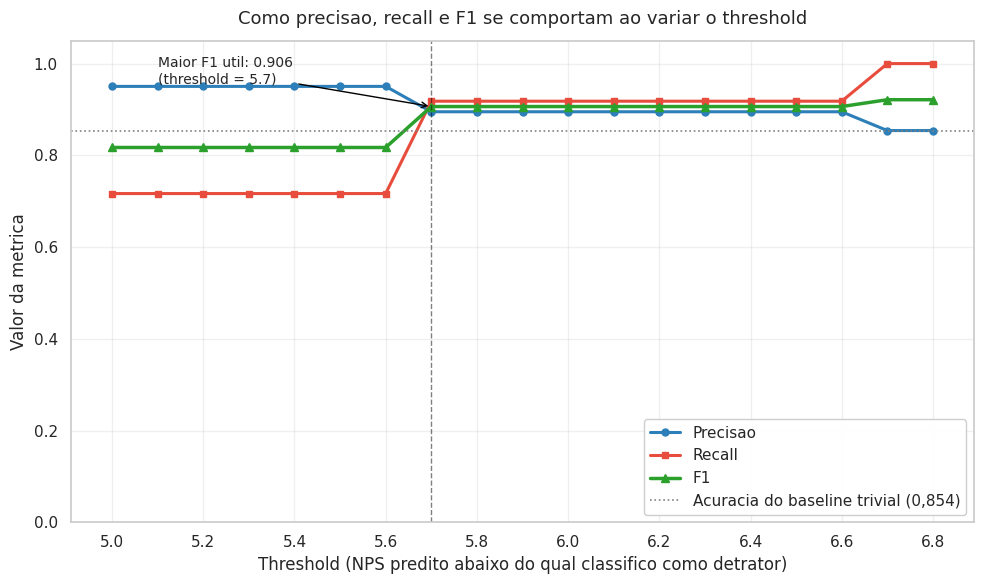

In [8]:
# Grafico de linhas: precisao, recall e F1 ao longo do threshold
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(tabela_thresholds["threshold"], tabela_thresholds["precisao"],
        label="Precisao", color="#2c7fb8", linewidth=2.2, marker="o", markersize=5)
ax.plot(tabela_thresholds["threshold"], tabela_thresholds["recall"],
        label="Recall", color=cores_buckets["detrator"], linewidth=2.2, marker="s", markersize=5)
ax.plot(tabela_thresholds["threshold"], tabela_thresholds["f1"],
        label="F1", color="#2ca02c", linewidth=2.5, marker="^", markersize=6)

# Linha do baseline
ax.axhline(0.854, color="gray", linestyle=":", linewidth=1.2,
           label="Acuracia do baseline trivial (0,854)")

# Anota o ponto de maior F1 (excluindo a regiao degenerada >= 6,7)
mascara_util = tabela_thresholds["threshold"] < 6.7
idx_melhor_f1 = tabela_thresholds.loc[mascara_util, "f1"].idxmax()
t_melhor = tabela_thresholds.loc[idx_melhor_f1, "threshold"]
f1_melhor = tabela_thresholds.loc[idx_melhor_f1, "f1"]
ax.axvline(t_melhor, color="black", linestyle="--", linewidth=1, alpha=0.5)
texto_anotacao = f"Maior F1 util: {f1_melhor:.3f}" + chr(10) + f"(threshold = {t_melhor:.1f})"
ax.annotate(texto_anotacao,
            xy=(t_melhor, f1_melhor),
            xytext=(t_melhor - 0.6, f1_melhor + 0.05),
            fontsize=10,
            arrowprops=dict(arrowstyle="->", color="black", lw=1))

ax.set_xlabel("Threshold (NPS predito abaixo do qual classifico como detrator)")
ax.set_ylabel("Valor da metrica")
ax.set_title("Como precisao, recall e F1 se comportam ao variar o threshold", fontsize=13, pad=12)
ax.set_ylim(0, 1.05)
ax.set_xticks(np.arange(5.0, 6.9, 0.2))
ax.legend(loc="lower right", framealpha=0.95)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(PASTA_FIGURAS / "6_5_metricas_por_threshold.png", dpi=120, bbox_inches="tight")
plt.show()


![Métricas de classificação em função do threshold](../reports/figures/06_modelagem_classificacao/6_5_metricas_por_threshold.png)


**Como ler este gráfico:** o eixo X é o threshold de NPS predito que separa detratores de não-detratores; o eixo Y é o valor da métrica entre 0 e 1. Três linhas estão sobrepostas: **precisão** em azul (proporção dos preditos como detrator que de fato eram detratores), **recall** em vermelho (proporção dos detratores reais que o modelo capturou) e **F1** em verde (média harmônica entre precisão e recall, usada para resumir os dois em um número só).

A linha pontilhada cinza horizontal marca a acurácia do baseline trivial (0,854), só para servir de referência. A linha pontilhada preta vertical marca o threshold com o maior F1 dentro da faixa útil (excluindo a região degenerada onde o threshold é tão alto que classifica todo mundo como detrator).

A primeira coisa que chama atenção são os **degraus** nas curvas. Em vez de transições suaves, as métricas ficam estáveis em platôs e dão saltos em pontos específicos do threshold. A explicação é direta: o `delivery_delay_days` é uma variável discreta (atraso medido em dias inteiros), e a regressão é linear, então o NPS predito também só assume um conjunto pequeno de valores possíveis. O classificador só muda de comportamento quando o threshold cruza um desses valores.

A leitura tem três partes.

**Comportamento da precisão (azul):** ela começa muito alta em thresholds baixos. Quando exijo NPS predito menor que 5,6 para chamar alguém de detrator, 95% dos apontados são detratores de verdade — porque essa região da reta corresponde a atrasos altos, e atraso alto na EDA já se mostrou um sinal forte de descontentamento. Conforme o threshold sobe, a precisão cai para 89,5% e fica nesse patamar dentro de uma faixa larga.

**Comportamento do recall (vermelho):** o oposto. Threshold baixo deixa muitos detratores reais passarem despercebidos (recall em 72%), e conforme subo o threshold capto cada vez mais detratores reais. A partir de 5,7 o recall sobe para 92% e estabiliza, até chegar a 100% quando o threshold ultrapassa o intercepto da reta.

**Comportamento do F1 (verde):** a curva sobe rápido e entra em platô a partir do threshold 5,7, com F1 igual a 0,906 (precisão 89,5% e recall 91,8%). Esse platô se mantém até o threshold 6,6. Em outras palavras, qualquer corte entre 5,7 e 6,6 produz exatamente o mesmo classificador na prática.

A coluna `preditos_detrator` na tabela impressa antes do gráfico ajuda a ler isso em termos operacionais. Com threshold 5,0 o modelo aponta cerca de 322 clientes para ação; com threshold no platô (5,7 a 6,6) aponta 438; com 6,7 sobe para os 500 do conjunto de teste inteiro. Entre essas pontas existe espaço para a operação calibrar o quanto está disposta a errar para cada lado.

A próxima seção fixa um threshold dentro do platô para olhar com mais detalhe quem o modelo está errando.


## 6.6 Análise dos erros do threshold escolhido

Para a análise de erros, fixo o threshold em 6,0, um ponto representativo do platô identificado na seção anterior (qualquer valor entre 5,7 e 6,6 produz o mesmo classificador). Nesse ponto, 89,5% dos preditos como detrator são detratores de verdade, e 91,8% dos detratores reais são capturados.

A pergunta agora é qualitativa. Quem são os clientes em cada um dos quatro quadrantes da matriz de confusão? Em particular, o que distingue os erros (falsos positivos e falsos negativos) dos acertos? Se houver um padrão claro, ele aponta para variáveis que poderiam entrar em uma versão mais elaborada do modelo.


In [9]:
# Fixa o threshold escolhido
threshold_operacional = 6.0
y_pred_det = (nps_predito_teste < threshold_operacional).astype(int)

# Recupera o subset de teste com index original alinhado as predicoes
teste_completo = dados.iloc[X_teste.index].reset_index(drop=True).copy()
teste_completo["nps_predito"] = nps_predito_teste.values
teste_completo["eh_detrator_pred"] = y_pred_det.values
teste_completo["eh_detrator_real"] = y_real_det.values

# Classifica cada cliente em um dos 4 quadrantes
def classificar_quadrante(linha):
    if linha["eh_detrator_real"] == 1 and linha["eh_detrator_pred"] == 1:
        return "TP (detrator capturado)"
    if linha["eh_detrator_real"] == 0 and linha["eh_detrator_pred"] == 0:
        return "TN (nao-detrator liberado)"
    if linha["eh_detrator_real"] == 0 and linha["eh_detrator_pred"] == 1:
        return "FP (alarme falso)"
    return "FN (detrator perdido)"

teste_completo["quadrante"] = teste_completo.apply(classificar_quadrante, axis=1)

print("Distribuicao dos quadrantes no teste com threshold 6,0:")
print(teste_completo["quadrante"].value_counts())


Distribuicao dos quadrantes no teste com threshold 6,0:
quadrante
TP (detrator capturado)       392
FP (alarme falso)              46
FN (detrator perdido)          35
TN (nao-detrator liberado)     27
Name: count, dtype: int64


In [10]:
# Compara medias de variaveis operacionais entre os 4 quadrantes
variaveis_comparar = [
    "delivery_delay_days",
    "customer_service_contacts",
    "complaints_count",
    "csat_internal_score",
    "nps_score",
]
labels_legiveis = {
    "delivery_delay_days":        "Atraso medio (dias)",
    "customer_service_contacts":  "Contatos com SAC",
    "complaints_count":           "Reclamacoes registradas",
    "csat_internal_score":        "CSAT interno",
    "nps_score":                  "NPS observado",
}

resumo = teste_completo.groupby("quadrante")[variaveis_comparar].mean().round(2)
# Reordena os quadrantes em ordem logica
ordem_quadrantes = [
    "TN (nao-detrator liberado)",
    "TP (detrator capturado)",
    "FP (alarme falso)",
    "FN (detrator perdido)",
]
resumo = resumo.loc[ordem_quadrantes]

print("Media das variaveis operacionais por quadrante:")
print(resumo)


Media das variaveis operacionais por quadrante:
                            delivery_delay_days  customer_service_contacts  \
quadrante                                                                    
TN (nao-detrator liberado)                 0.00                       1.22   
TP (detrator capturado)                    2.64                       1.65   
FP (alarme falso)                          1.39                       0.87   
FN (detrator perdido)                      0.00                       2.17   

                            complaints_count  csat_internal_score  nps_score  
quadrante                                                                     
TN (nao-detrator liberado)              2.74                 5.54       8.68  
TP (detrator capturado)                 4.54                 2.45       3.50  
FP (alarme falso)                       2.78                 4.58       8.12  
FN (detrator perdido)                   4.20                 4.36       5.45  


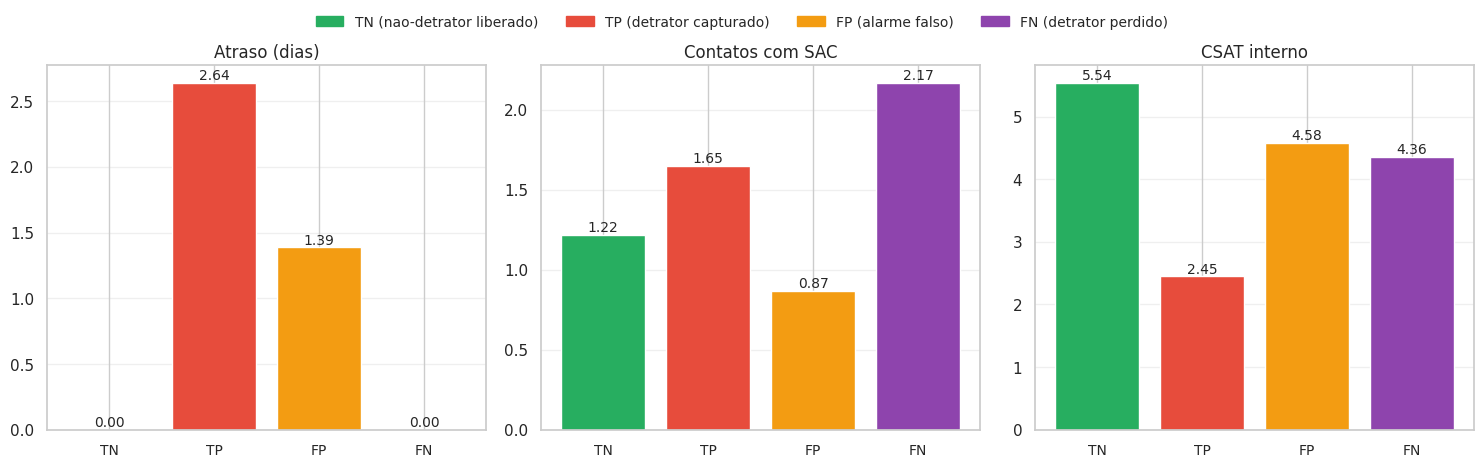

In [11]:
# Grafico de barras agrupadas comparando os quadrantes
variaveis_plot = ["delivery_delay_days", "customer_service_contacts", "csat_internal_score"]
labels_plot = ["Atraso (dias)", "Contatos com SAC", "CSAT interno"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=False)

cores_quadrantes = {
    "TN (nao-detrator liberado)": cores_buckets["promotor"],
    "TP (detrator capturado)":    cores_buckets["detrator"],
    "FP (alarme falso)":          "#f39c12",
    "FN (detrator perdido)":      "#8e44ad",
}

for ax, variavel, label in zip(axes, variaveis_plot, labels_plot):
    valores = resumo[variavel]
    cores = [cores_quadrantes[q] for q in valores.index]
    barras = ax.bar(range(len(valores)), valores.values, color=cores, edgecolor="white")
    ax.set_xticks(range(len(valores)))
    ax.set_xticklabels(["TN", "TP", "FP", "FN"], fontsize=10)
    ax.set_title(label, fontsize=12)
    ax.grid(True, axis="y", alpha=0.3)

    for barra, valor in zip(barras, valores.values):
        ax.text(barra.get_x() + barra.get_width()/2, valor,
                f"{valor:.2f}",
                ha="center", va="bottom", fontsize=10)

# Legenda compartilhada na lateral
handles = [plt.Rectangle((0,0),1,1, color=cores_quadrantes[q]) for q in ordem_quadrantes]
fig.legend(handles, ordem_quadrantes, loc="upper center", bbox_to_anchor=(0.5, 1.05),
           ncol=4, frameon=False, fontsize=10)

plt.tight_layout()
plt.savefig(PASTA_FIGURAS / "6_6_perfil_quadrantes.png", dpi=120, bbox_inches="tight")
plt.show()


![Perfil operacional médio por quadrante da matriz de confusão](../reports/figures/06_modelagem_classificacao/6_6_perfil_quadrantes.png)


**Como ler este gráfico:** três painéis lado a lado, cada um mostrando uma variável operacional. Em cada painel, o eixo X tem os quatro quadrantes da matriz de confusão (TN = não-detrator liberado, TP = detrator capturado, FP = alarme falso, FN = detrator perdido) e o eixo Y é a média da variável naquele quadrante. As cores marcam o quadrante: verde para TN (acerto positivo), vermelho para TP (acerto da classe alvo), laranja para FP (falso alarme) e roxo para FN (detrator que escapou). Os números acima de cada barra são os valores médios.

A leitura conta uma história sobre o que o modelo está vendo e o que ele não está vendo.

**No painel de atraso médio**, vale notar antes da interpretação que TN e FN têm atraso médio igual a zero. Isso não é coincidência: dado o threshold escolhido e a equação da reta, a fronteira do classificador fica exatamente em "atraso ≥ 1 dia". Logo, todo cliente com atraso zero é classificado como não-detrator pelo modelo, e os dois quadrantes de "predito não-detrator" (TN e FN) só contêm clientes sem atraso. Já os TPs (detratores capturados) têm atraso médio de 2,64 dias e os FPs (alarmes falsos), 1,39 dias. Isso confirma que o modelo está usando bem a única variável que recebeu.

**Nos painéis de contatos com SAC e CSAT interno**, aparece o ponto importante: os FNs (detratores que escaparam) têm a **maior média de contatos com SAC entre os quatro quadrantes** (2,17 contatos, contra 1,22 dos TNs) e **CSAT interno mais baixo** que os TNs (4,36 contra 5,54). Ou seja, esses clientes deram outros sinais de insatisfação que não estão na regressão. O modelo só olha atraso, e a entrega deles foi tranquila, então ele os classificou como não-detrator — mas eles ficaram insatisfeitos por outros motivos.

Isso é uma indicação clara para uma versão futura do modelo. Adicionar `customer_service_contacts` e `csat_internal_score` provavelmente reduziria os falsos negativos. Cabe um comentário honesto: este projeto se propôs ao modelo enxuto, e a versão multivariada com mais de dez variáveis já foi testada na EDA do notebook 04 (chegou a R² de 0,56 ali). A análise de erros aqui mostra exatamente onde o ganho viria — não em qualquer cliente, mas naqueles cujo problema não foi de logística.

Os FPs (alarmes falsos) têm o padrão oposto: atraso na entrega, mas o cliente acabou sendo neutro ou promotor. Eles têm inclusive **menos contatos com o SAC** (0,87) que a média dos TNs, sugerindo que são clientes "tolerantes" — toleraram um pedido com problemas e não rebaixaram a nota nem reclamaram. Pelo lado da operação, **errar para esse lado é menos ruim**: um contato preventivo com um cliente que estava prestes a virar detrator (mas não virou) é menos custoso do que perder um detrator que reclamou nas redes sociais sem o SAC ter sido acionado.


## 6.7 Conclusão da fase

A classificação por threshold transformou o output numérico da regressão em uma decisão binária pronta para a operação. O caminho até o threshold operacional foi educativo por si só.

### O que foi aprendido

O threshold "óbvio" de 7 é matematicamente equivalente ao baseline trivial: como o intercepto da reta já está em 6,63, todo cliente recebe predição abaixo de 7 e o classificador não consegue agregar nenhuma informação. A acurácia de 85,4% que ele entrega é exatamente a proporção da classe majoritária, sem nenhum mérito do modelo. Esse foi o aprendizado mais importante deste notebook.

A varredura de thresholds mostrou que o classificador só começa a valer a pena em valores mais conservadores. A partir de 5,7 o F1 atinge seu platô em 0,906 com precisão de 89,5% e recall de 91,8%, e mantém esse patamar até 6,6. Como o `delivery_delay_days` é discreto, o modelo só muda de comportamento em pontos específicos do threshold; qualquer escolha dentro desse intervalo produz o mesmo classificador.

A análise de erros explicou tanto os acertos quanto os limites do modelo. Os falsos negativos (detratores que escaparam) são clientes cujo problema não foi de logística: a entrega chegou no prazo (atraso zero), mas tiveram em média 2,17 contatos com o SAC e CSAT interno baixo. O modelo enxuto não tem como pegá-los. Os falsos positivos são o oposto: clientes que tiveram entrega com atraso mas não rebaixaram a nota e nem procuraram o SAC.

### Threshold recomendado

A recomendação operacional é usar **threshold 6,0**. Como o classificador se comporta de forma idêntica em qualquer ponto entre 5,7 e 6,6, escolhi um valor redondo dentro desse intervalo, fácil de comunicar para o time da operação. Ele entrega a melhor combinação de precisão e recall fora da região degenerada e na prática traduz a regra como "todo cliente com atraso de 1 dia ou mais entra na lista de ação".

Para usos diferentes do classificador, valeria escolher outro corte. Se a operação tiver capacidade limitada para acionar o SAC e quiser focar nos casos mais críticos, faz sentido subir a precisão usando threshold abaixo de 5,7 — o modelo aponta menos clientes, mas 95% deles são detratores de verdade. Se a operação quiser cobrir o máximo possível de detratores aceitando algum desperdício, dá para esticar até a vizinhança do intercepto, sabendo que o ganho é limitado.

### Conexão com a regressão

Vale notar que classificação e regressão não são abordagens concorrentes neste projeto: são duas leituras do mesmo modelo. A regressão entrega um número contínuo que pode alimentar dashboards e ranqueamentos; a classificação entrega uma decisão binária pronta para acionar workflow. Os dois usam exatamente a mesma reta ajustada no notebook 05; a diferença é só como o output é apresentado.

### O que fica pendente

A análise de erros apontou que os falsos negativos têm assinatura em outras variáveis (contatos com SAC e CSAT interno). Em uma fase futura do projeto, fora do escopo deste tech challenge, a expansão natural do modelo seria multivariada, incluindo essas variáveis. A justificativa para não ter feito isso aqui foi consciente: o objetivo da Fase 1 era um modelo enxuto, defensável e estatisticamente válido com as ferramentas vistas em aula, e essa decisão se manteve.

A próxima fase do trabalho é a avaliação consolidada (notebook 07) e o storytelling executivo, onde os resultados destes seis notebooks viram uma recomendação fechada para a área de negócio.
